In [25]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict
from IPython.display import Image , display
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

True

In [13]:
##BMI CALCULATOR

In [27]:
model = ChatOpenAI()

In [19]:
class BMIState(TypedDict):
    weight_kg: float
    height_m : float
    bmi : float
    category : str

In [15]:
def calculate_bmi(state:BMIState)-> BMIState:
    state['bmi'] = state['weight_kg'] / (state['height_m'] ** 2)
    return state

In [20]:
def label_BMI(state:BMIState)-> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

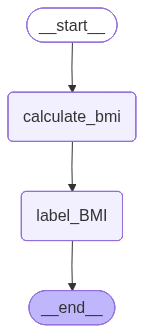

In [21]:
graph = StateGraph(BMIState)
#add nodes
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_BMI' , label_BMI)

#ADD EDGES
graph.add_edge(START , 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_BMI')
graph.add_edge('label_BMI', END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [23]:
graph_builder.invoke({
    'weight_kg': 88,
    'height_m': 1.95
})

{'weight_kg': 88,
 'height_m': 1.95,
 'bmi': 23.14266929651545,
 'category': 'Normal weight'}

In [26]:
#State

class LLMState(TypedDict):
    question : str
    answer : str

In [28]:
def llm_qa(state:LLMState)-> LLMState:
    question = state['question']
    prompt = f'Answer the following question: {question}'
    answer = model.invoke(prompt).content
    state['answer'] = answer
    return state

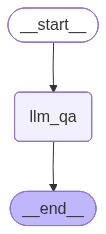

In [29]:
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)
graph.add_edge(START , 'llm_qa')
graph.add_edge('llm_qa', END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [30]:
initial_state = {'question': 'How far is the moon from the EARTH'}

final_state = graph_builder.invoke(initial_state)

print(final_state)

{'question': 'How far is the moon from the EARTH', 'answer': 'The average distance from the Earth to the Moon is about 384,400 kilometers (238,855 miles).'}
